# Visualizzazione Avanzata Risultati e Anatomia Lesionale 3D

Questo notebook permette di caricare un output salvato della pipeline (da `results/`) e visualizzare lo spazio di embedding in 2D e 3D.

Inoltre, consente di selezionare un soggetto e visualizzare la sua lesione cerebrale in un visualizzatore 3D interattivo direttamente nel notebook.

In [5]:
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from nilearn import plotting
from IPython.display import display
import itertools
import seaborn as sns
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registra la projection "3d"



# Aggiunge la directory root del progetto al path per importare src
# Risale da cwd fino a trovare la root del repo (contiene environment.yml) - non assume un
# numero fisso di livelli: cwd dipende da come il kernel Jupyter e' stato lanciato (IDE/editor),
# non dalla posizione del notebook sul filesystem (bug trovato 13-08: Path.cwd().parent falliva
# per i notebook annidati sotto notebooks/<sottocartella>/, es. questo file).
root_path = Path.cwd()
while not (root_path / "environment.yml").exists():
    if root_path.parent == root_path:
        raise RuntimeError(
            "could not locate project root (no environment.yml found in any parent directory of "
            f"{Path.cwd()}) - run this notebook with a working directory somewhere inside the NEMESIS repo"
        )
    root_path = root_path.parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.utils.artifacts import load_matrix
import nibabel as nib
from src.features.lesion import load_reference_image
from src.features.clinical import join_lesion_side
from src.analysis.embedding_coloring import COLOR_MODES
from src.analysis.plotting import _CATEGORICAL_PALETTE, _NOISE_COLOR, _MARKER_SIZE, _AXIS_PADDING_FRACTION

print("Librerie importate correttamente.")
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")


Librerie importate correttamente.


In [6]:
# Stessa mappa di scripts/replot_dim_reduction.py::_PERSISTED_COLUMN_BY_MODE - leggiamo le colonne
# gia' persistite in metadata.csv a tempo di produzione, non le ricalcoliamo mai qui (qui X e'
# l'embedding, non la matrice voxel grezza che COLOR_MODES[...].compute si aspetterebbe).
_PERSISTED_COLUMN_BY_MODE = {
    "dataset": "dataset",
    "side": "lesion_side",
    "volume": "lesion_volume_voxels",
    "nihss": "nihss",
}


def _palette_for(categories, missing_label="unknown"):
    palette, colors = {}, itertools.cycle(_CATEGORICAL_PALETTE)
    for cat in categories:
        palette[cat] = _NOISE_COLOR if cat == missing_label else next(colors)
    return palette

## 1. Caricamento del Risultato della Pipeline

Scegliere la cartella dei risultati da ispezionare (dim_reduction ). Il notebook caricherà l'embedding e i metadati associati.

In [7]:
# Percorso dei risultati (modificare a piacimento)
results_dir = root_path / "results/lesion/dim_reduction/production/umap/11-08_s1.1_nc2_m_euclidean"

if not results_dir.exists():
    parent_results = root_path / "results/lesion/dim_reduction"
    subdirs = sorted([d for d in parent_results.glob("**/*") if d.is_dir() and (d / "manifest.json").exists()])
    if subdirs:
        results_dir = subdirs[-1]
        print(f"Cartella di fallback trovata: {results_dir}")
    else:
        parent_results = root_path / "results/lesion/dim_reduction_clustering"
        subdirs = sorted([d for d in parent_results.glob("**/*") if d.is_dir() and (d / "manifest.json").exists()])
        if subdirs:
            results_dir = subdirs[-1]
            print(f"Cartella di fallback trovata: {results_dir}")


try:
    embedding, metadata, extra_arrays = load_matrix(results_dir)
    print(f"Risultati caricati con successo da: {results_dir}")
    print(f"Shape dell'embedding: {embedding.shape}")
    print(f"Colonne metadati: {list(metadata.columns)}")
    
    # Assicuriamoci che lesion_side sia presente
    if "lesion_side" not in metadata.columns:
        metadata["lesion_side"] = join_lesion_side(metadata)
        
except Exception as e:
    print(f"Errore: impossibile caricare i risultati da {results_dir}. Assicurarsi che la pipeline abbia prodotto dei risultati. Dettaglio: {e}")

Risultati caricati con successo da: /Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/results/lesion/dim_reduction/production/umap/11-08_s1.1_nc2_m_euclidean
Shape dell'embedding: (1150, 2)
Colonne metadati: ['subject_id', 'dataset', 'lesion_volume_voxels', 'lesion_side', 'nihss']


## 2. Visualizzazione 2D degli Embedding

In [31]:
# Un pannello per ognuna, nell'ordine dato qui - stessi nomi di COLOR_MODES.
color_by = ["dataset", "side", "volume", "nihss"]

In [29]:
def plot_embedding_panel(ax, X_2d, mode_name, metadata, title, xlabel, ylabel):
    mode = COLOR_MODES[mode_name]
    values = metadata[_PERSISTED_COLUMN_BY_MODE[mode_name]].to_numpy()

    x_min, x_max = X_2d[:, 0].min(), X_2d[:, 0].max()
    y_min, y_max = X_2d[:, 1].min(), X_2d[:, 1].max()
    x_pad = (x_max - x_min) * _AXIS_PADDING_FRACTION
    y_pad = (y_max - y_min) * _AXIS_PADDING_FRACTION
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    if mode.kind == "categorical":
        unique_categories = sorted(pd.unique(values).tolist())
        sns.scatterplot(
            x=X_2d[:, 0], y=X_2d[:, 1], hue=values, hue_order=unique_categories,
            palette=_palette_for(unique_categories), s=_MARKER_SIZE, edgecolor="none",
            legend="full", ax=ax,
        )
        ax.legend(title=mode.label, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, fontsize=8)
    else:
        values = np.asarray(values, dtype=float)
        is_missing = np.isnan(values)
        norm = None
        if mode.log_scale and (~is_missing).any():
            norm = mcolors.LogNorm(vmin=values[~is_missing].min(), vmax=values[~is_missing].max())
        if is_missing.any():
            ax.scatter(X_2d[is_missing, 0], X_2d[is_missing, 1], c=_NOISE_COLOR, s=_MARKER_SIZE, edgecolor="none", label="missing")
        scatter = ax.scatter(X_2d[~is_missing, 0], X_2d[~is_missing, 1], c=values[~is_missing], cmap="viridis", norm=norm, s=_MARKER_SIZE, edgecolor="none")
        ax.get_figure().colorbar(scatter, ax=ax, label=mode.label, fraction=0.046, pad=0.04)
        if is_missing.any():
            ax.legend(loc="upper right", framealpha=0.9, fontsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight="bold")


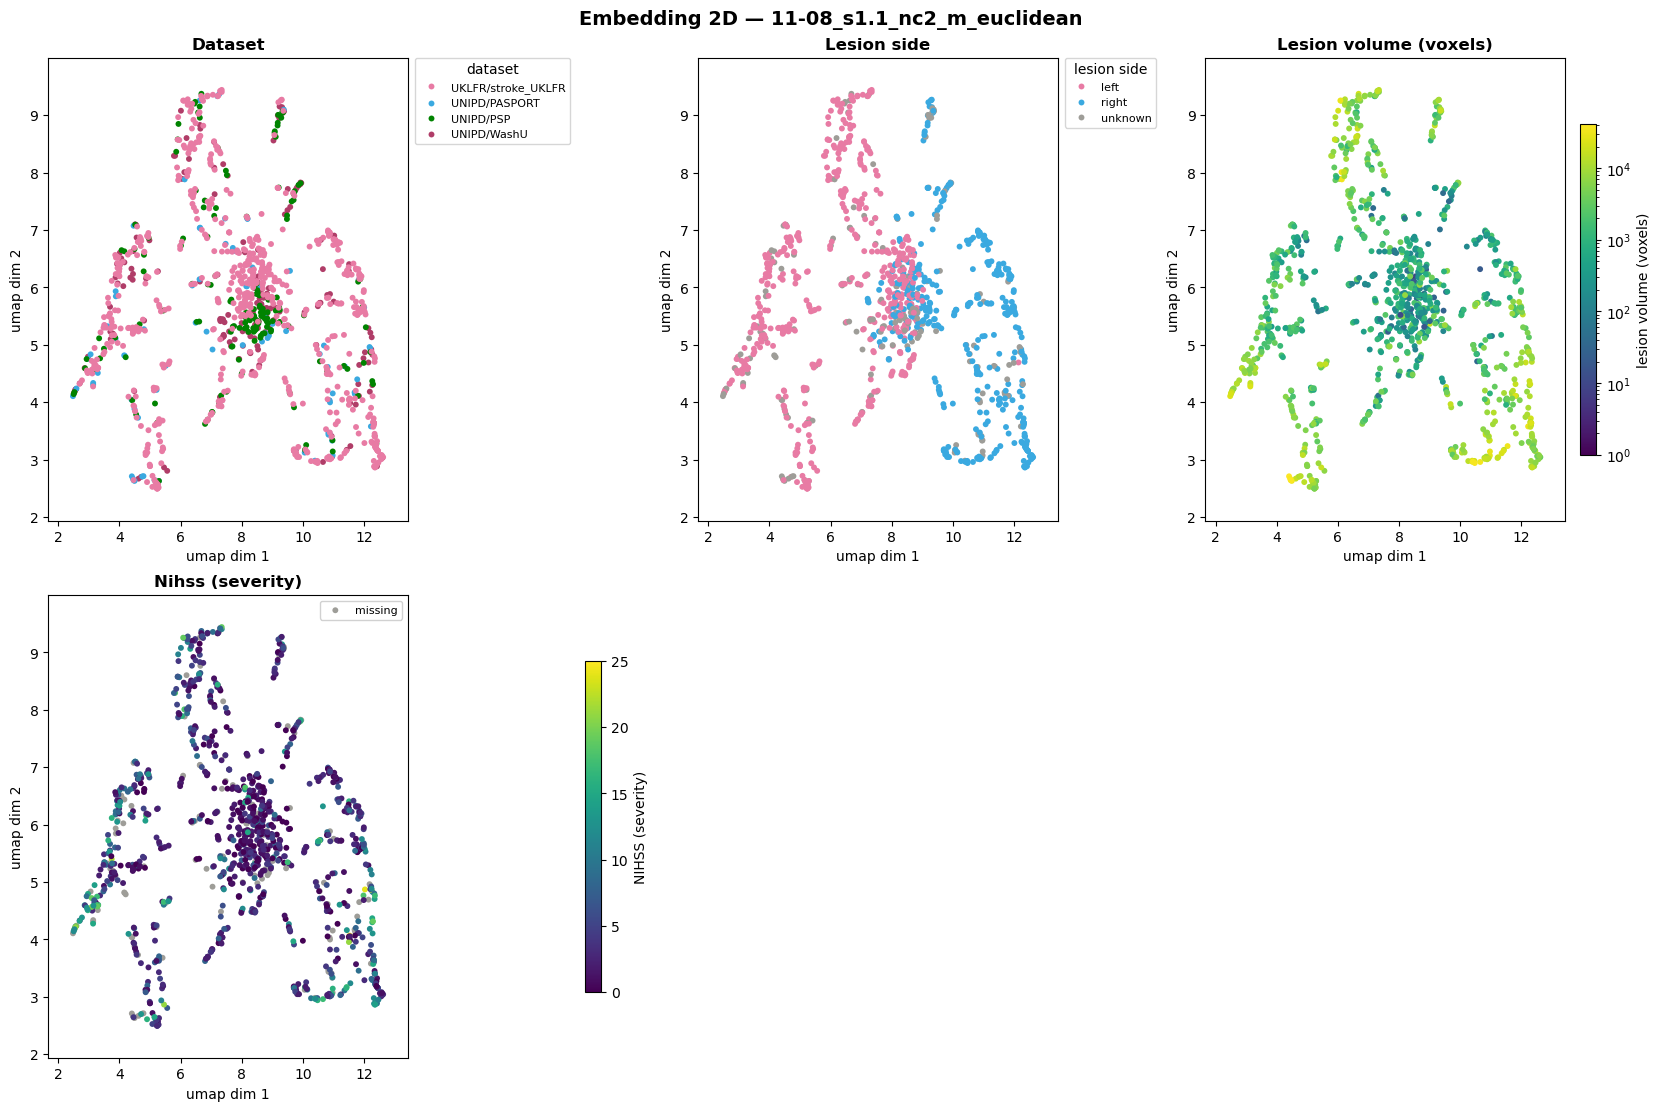

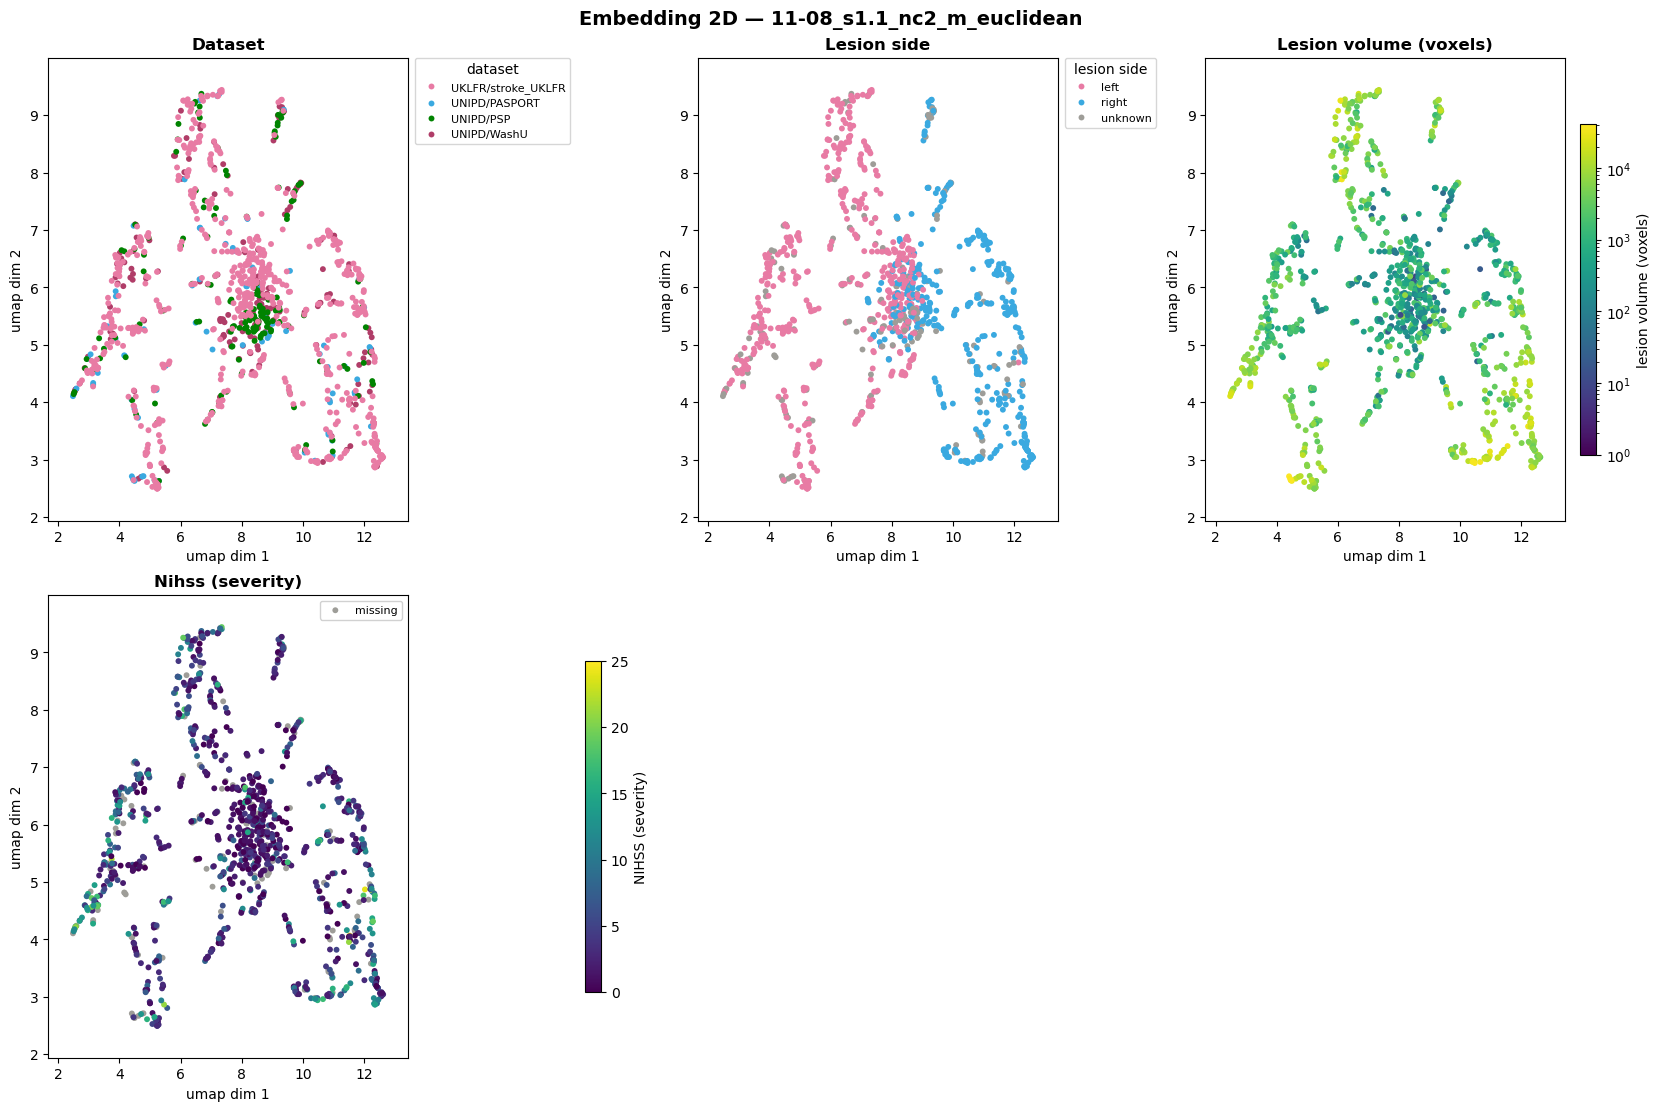

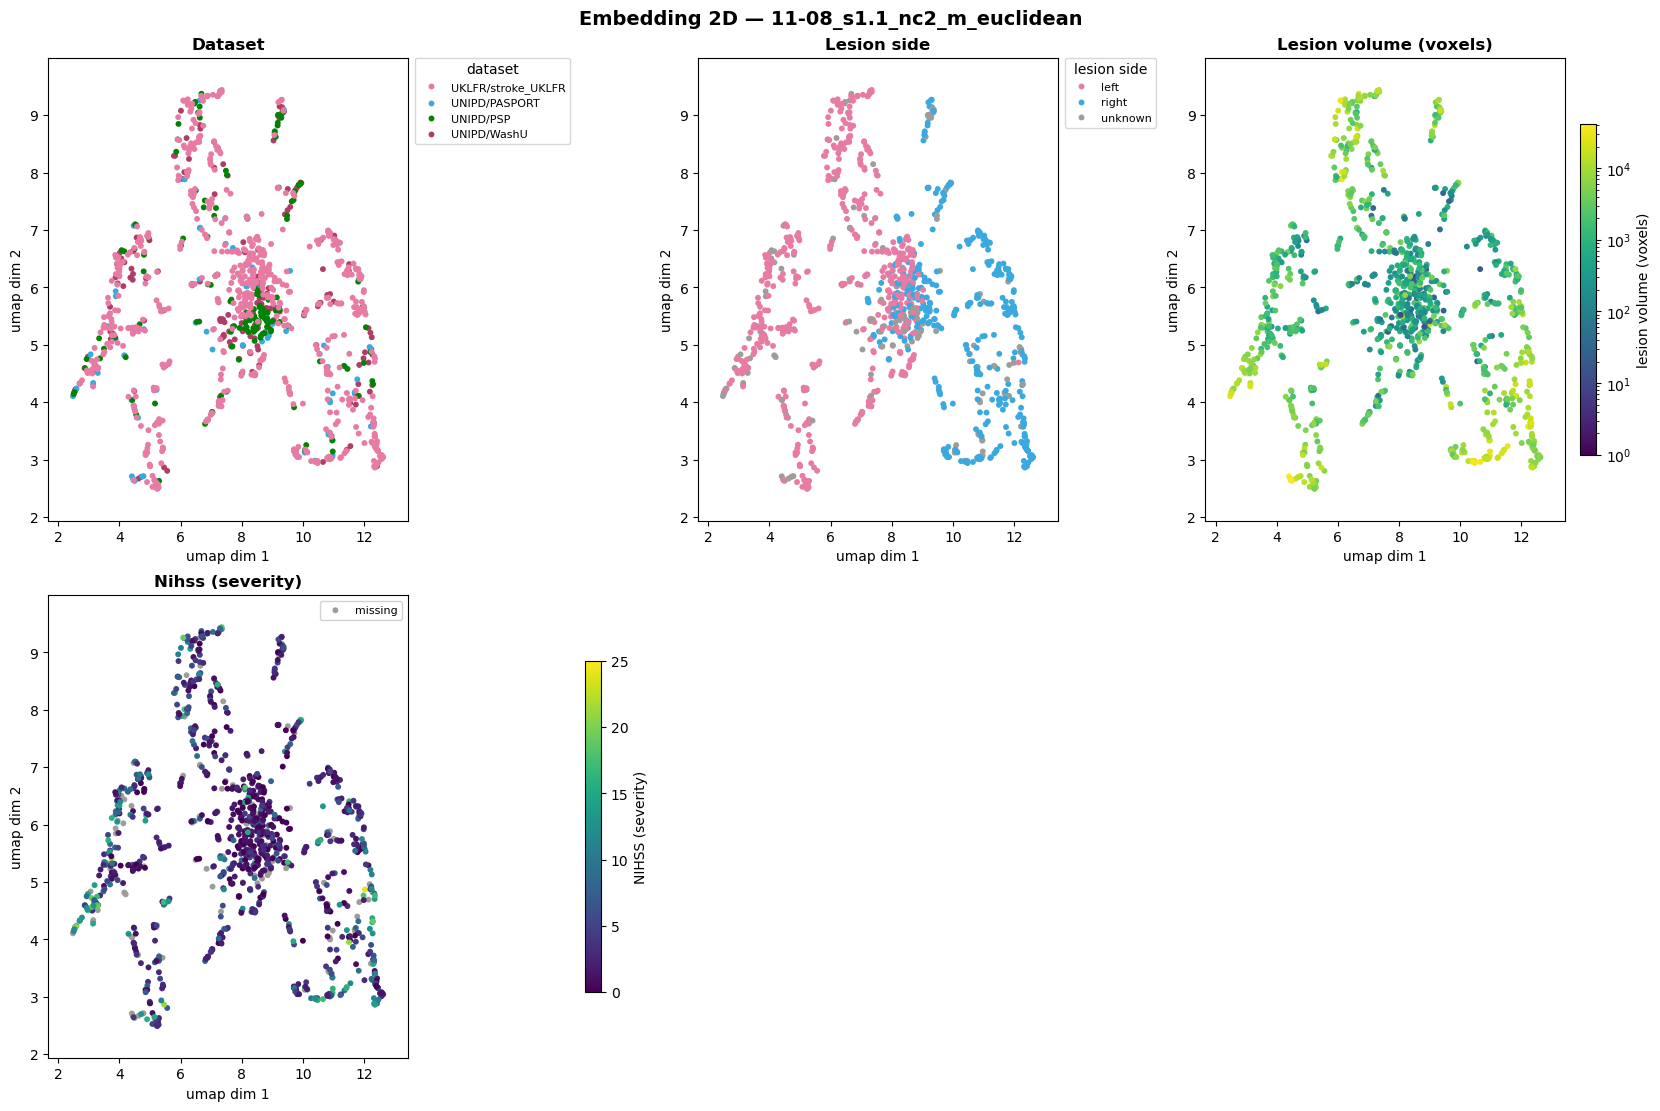

In [30]:
if 'embedding' in locals() and embedding.shape[1] >= 2:
    n_panels = len(color_by)
    ncols = min(3, n_panels)
    nrows = -(-n_panels // ncols)  # ceil
    panel_size = 5.5  # stessa dimensione per ogni box

    fig, axs = plt.subplots(nrows, ncols, figsize=(panel_size * ncols, panel_size * nrows), constrained_layout=True)
    axs = np.atleast_1d(axs).flatten()

    for ax, name in zip(axs, color_by):
        plot_embedding_panel(ax, embedding[:, :2], name, metadata, COLOR_MODES[name].label.capitalize(), "umap dim 1", "umap dim 2")
    for ax in axs[n_panels:]:
        ax.axis("off")

    fig.suptitle(f"Embedding 2D — {results_dir.name}", fontsize=14, fontweight="bold")
    plt.show()
else:
    print("Dati non caricati o embedding con meno di 2 dimensioni.")


In [8]:
import tempfile
from IPython.display import Image, display
from src.analysis.plotting import plot_embedding_2d, plot_embedding_categorical, plot_embedding_continuous


def show_embedding_single(X_2d, mode_name, metadata, title, xlabel, ylabel):
    """Disegna un plot singolo con le funzioni REALI della pipeline (le stesse
    che hanno prodotto embedding_plot_*.png in produzione) - mai una
    reimplementazione a mano. mode_name="neutro" -> nessuna colorazione
    (embedding_plot_unico.png), altrimenti uno dei nomi di COLOR_MODES."""
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        output_path = Path(tmp.name)

    if mode_name == "neutro":
        plot_embedding_2d(X_2d, output_path, xlabel, ylabel, title)
    else:
        mode = COLOR_MODES[mode_name]
        values = metadata[_PERSISTED_COLUMN_BY_MODE[mode_name]].to_numpy()
        if mode.kind == "categorical":
            plot_embedding_categorical(X_2d, values, output_path, xlabel, ylabel, title, legend_title=mode.label)
        else:
            plot_embedding_continuous(X_2d, values, output_path, xlabel, ylabel, title, colorbar_label=mode.label, log_scale=mode.log_scale)

    display(Image(filename=str(output_path)))


In [9]:
# "neutro" (nessuna colorazione) oppure uno dei nomi di COLOR_MODES: "dataset", "side", "volume", "nihss"
single_color_by = "neutro"


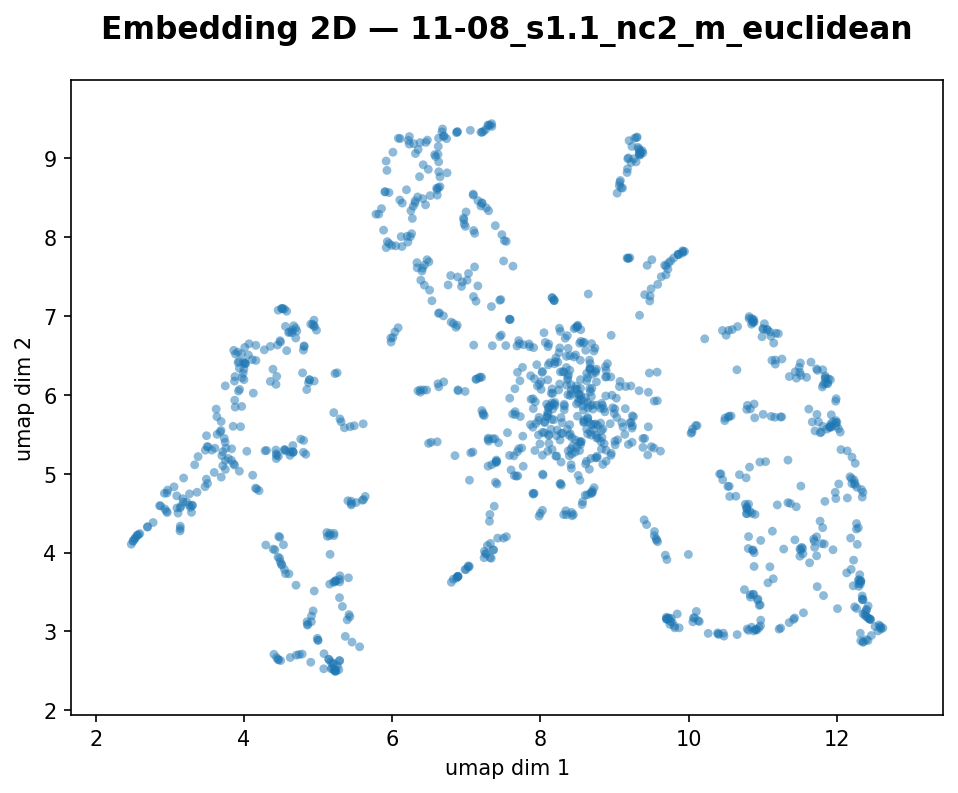

In [10]:
if 'embedding' in locals() and embedding.shape[1] >= 2:
    show_embedding_single(embedding[:, :2], single_color_by, metadata, f"Embedding 2D — {results_dir.name}", "umap dim 1", "umap dim 2")
else:
    print("Dati non caricati o embedding con meno di 2 dimensioni.")


In [11]:
color_by = ["dataset", "side", "volume", "nihss"]


In [12]:
def plot_embedding_panel(ax, X_2d, mode_name, metadata, title, xlabel, ylabel):
    mode = COLOR_MODES[mode_name]
    values = metadata[_PERSISTED_COLUMN_BY_MODE[mode_name]].to_numpy()

    x_min, x_max = X_2d[:, 0].min(), X_2d[:, 0].max()
    y_min, y_max = X_2d[:, 1].min(), X_2d[:, 1].max()
    x_pad = (x_max - x_min) * _AXIS_PADDING_FRACTION
    y_pad = (y_max - y_min) * _AXIS_PADDING_FRACTION
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    if mode.kind == "categorical":
        unique_categories = sorted(pd.unique(values).tolist())
        sns.scatterplot(
            x=X_2d[:, 0], y=X_2d[:, 1], hue=values, hue_order=unique_categories,
            palette=_palette_for(unique_categories), s=_MARKER_SIZE, edgecolor="none",
            legend="full", ax=ax,
        )
        ax.legend(title=mode.label, loc="best", fontsize=7, title_fontsize=8, framealpha=0.85, markerscale=0.8)
    else:
        values = np.asarray(values, dtype=float)
        is_missing = np.isnan(values)
        norm = None
        if mode.log_scale and (~is_missing).any():
            norm = mcolors.LogNorm(vmin=values[~is_missing].min(), vmax=values[~is_missing].max())
        if is_missing.any():
            ax.scatter(X_2d[is_missing, 0], X_2d[is_missing, 1], c=_NOISE_COLOR, s=_MARKER_SIZE, edgecolor="none", label="missing")
        scatter = ax.scatter(X_2d[~is_missing, 0], X_2d[~is_missing, 1], c=values[~is_missing], cmap="viridis", norm=norm, s=_MARKER_SIZE, edgecolor="none")
        ax.get_figure().colorbar(scatter, ax=ax, label=mode.label, fraction=0.046, pad=0.04)
        if is_missing.any():
            ax.legend(loc="best", framealpha=0.85, fontsize=7)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight="bold")


In [14]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

In [16]:
from IPython.display import display
display(fig)


<Figure size 1650x1100 with 8 Axes>

In [17]:
if 'embedding' in locals() and embedding.shape[1] >= 2:
    n_panels = len(color_by)
    ncols = min(3, n_panels)
    nrows = -(-n_panels // ncols)  # ceil
    panel_size = 5.5  # stessa dimensione per ogni box

    fig, axs = plt.subplots(nrows, ncols, figsize=(panel_size * ncols, panel_size * nrows), constrained_layout=True)
    axs = np.atleast_1d(axs).flatten()

    for ax, name in zip(axs, color_by):
        plot_embedding_panel(ax, embedding[:, :2], name, metadata, COLOR_MODES[name].label.capitalize(), "umap dim 1", "umap dim 2")
    for ax in axs[n_panels:]:
        ax.axis("off")

    fig.suptitle(f"Embedding 2D — {results_dir.name}", fontsize=14, fontweight="bold")
    plt.show()
else:
    print("Dati non caricati o embedding con meno di 2 dimensioni.")


<Figure size 1650x1100 with 8 Axes>

## 3. Visualizzazione Interattiva in 3D (Plotly)

In [ ]:
tuning_dir_3d = root_path / "results/lesion/dim_reduction/tuning/umap/13-08_s1.1"
embeddings_npz = np.load(tuning_dir_3d / "embeddings.npz")

# Scegli qui la combinazione esatta (stessa chiave leggibile di tuning_results.csv - vedi
# src/pipeline/dim_reduction.py::_combo_key, ordine metric,n_components,n_neighbors,min_dist)
combo_key_3d = "metric=dice,n_components=3,n_neighbors=15,min_dist=0.1"

if combo_key_3d not in embeddings_npz:
    raise KeyError(
        f"{combo_key_3d!r} non tra le combinazioni salvate - alcune disponibili: {list(embeddings_npz.keys())[:8]}"
    )
embedding_3d = embeddings_npz[combo_key_3d]
metadata_3d = pd.read_csv(tuning_dir_3d / "metadata.csv")
print(f"Embedding 3D caricato: shape {embedding_3d.shape}")


In [ ]:
def plot_embedding_panel_3d(ax, X_3d, mode_name, metadata, title, xlabel, ylabel, zlabel):
    mode = COLOR_MODES[mode_name]
    values = metadata[_PERSISTED_COLUMN_BY_MODE[mode_name]].to_numpy()

    if mode.kind == "categorical":
        unique_categories = sorted(pd.unique(values).tolist())
        palette = _palette_for(unique_categories)
        for cat in unique_categories:
            mask = values == cat
            ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2], color=palette[cat], s=_MARKER_SIZE, edgecolor="none", label=cat)
        ax.legend(title=mode.label, loc="upper left", bbox_to_anchor=(1.05, 1.0), borderaxespad=0.0, fontsize=8)
    else:
        values = np.asarray(values, dtype=float)
        is_missing = np.isnan(values)
        norm = None
        if mode.log_scale and (~is_missing).any():
            norm = mcolors.LogNorm(vmin=values[~is_missing].min(), vmax=values[~is_missing].max())
        if is_missing.any():
            ax.scatter(X_3d[is_missing, 0], X_3d[is_missing, 1], X_3d[is_missing, 2], c=_NOISE_COLOR, s=_MARKER_SIZE, edgecolor="none", label="missing")
        scatter = ax.scatter(X_3d[~is_missing, 0], X_3d[~is_missing, 1], X_3d[~is_missing, 2], c=values[~is_missing], cmap="viridis", norm=norm, s=_MARKER_SIZE, edgecolor="none")
        ax.get_figure().colorbar(scatter, ax=ax, label=mode.label, fraction=0.046, pad=0.1, shrink=0.7)
        if is_missing.any():
            ax.legend(loc="upper right", framealpha=0.9, fontsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title, fontsize=12, fontweight="bold")


In [ ]:
if 'embedding_3d' in locals() and embedding_3d.shape[1] >= 3:
    n_panels = len(color_by)
    ncols = min(3, n_panels)
    nrows = -(-n_panels // ncols)
    panel_size = 6.0

    fig, axs = plt.subplots(nrows, ncols, figsize=(panel_size * ncols, panel_size * nrows),
                             subplot_kw={"projection": "3d"}, constrained_layout=True)
    axs = np.atleast_1d(axs).flatten()

    for ax, name in zip(axs, color_by):
        plot_embedding_panel_3d(ax, embedding_3d[:, :3], name, metadata_3d, COLOR_MODES[name].label.capitalize(),
                                 "umap dim 1", "umap dim 2", "umap dim 3")
    for ax in axs[n_panels:]:
        ax.axis("off")

    fig.suptitle(f"Embedding 3D — {combo_key_3d}", fontsize=14, fontweight="bold")
    plt.show()
else:
    print("Embedding 3D non caricato o con meno di 3 componenti.")


## 4. Visualizzatore 3D Interattivo di Anatomia Lesionale (Nilearn)

Selezionando il codice di un soggetto (es. `sub-STUNIPD0001`), cerchiamo il suo file NIfTI originale e lo visualizziamo in 3D overlayato su un cervello standard MNI152.

In [12]:
if 'metadata' in locals():
    # Inserisci il subject_id da ispezionare
    selected_subject = "sub-STUNIPD0001" 

    # Percorso principale dei dati clinici BIDS
    data_root = Path("../data/clinical_connectome/derivatives")

    # Troviamo il dataset del soggetto cercato
    if selected_subject in metadata["subject_id"].values:
        subject_row = metadata[metadata["subject_id"] == selected_subject].iloc[0]
        dataset_name = subject_row.get("dataset", subject_row.get("dataset_x", None))
        
        if dataset_name:
            # Costruiamo il percorso del manual mask
            lesion_dir = data_root / dataset_name / "manual_masks" / selected_subject / "anat"
            lesion_files = list(lesion_dir.glob("*_label-lesion_mask.nii.gz"))
            
            if lesion_files:
                lesion_path = lesion_files[0]
                print(f"Trovata lesione per {selected_subject} in: {lesion_path}")
                print("Caricamento del visualizzatore 3D interattivo (puoi ruotare, zoomare e selezionare i piani di taglio)...")
                
                # Creiamo il visualizzatore 3D di Nilearn
                view = plotting.view_img(
                    str(lesion_path), 
                    threshold=0.5, 
                    bg_img="MNI152", 
                    title=f"Lesione: {selected_subject} ({dataset_name})"
                )
                # Mostra la view interattiva nel cell output
                display(view)
            else:
                print(f"Errore: Nessun file NIfTI lesion_mask trovato in {lesion_dir}")
        else:
            print(f"Errore: Dataset non trovato nei metadati per {selected_subject}")
    else:
        available_subjects = list(metadata["subject_id"].head(10))
        print(f"Soggetto {selected_subject} non presente in questa matrice.")
        print(f"Esempi di soggetti disponibili nella matrice corrente: {available_subjects}")
else:
    print("Dati non caricati.")

Errore: Nessun file NIfTI lesion_mask trovato in ../data/clinical_connectome/derivatives/UNIPD/WashU/manual_masks/sub-STUNIPD0001/anat


## 5. Distribuzione Topografica delle Lesioni per Cluster (Overlap Map)

Per ogni cluster, sovrapponiamo le maschere di lesione binarie di tutti i soggetti che ne fanno parte e calcoliamo, voxel per voxel, la **frequenza** con cui quel punto del cervello risulta lesionato all'interno del cluster (0 = mai, 1 = sempre). È l'analisi standard di "lesion overlap map" usata in letteratura (es. Corbetta et al. 2015) per capire se un cluster corrisponde a un pattern topografico coerente o a lesioni sparse.

La ricostruzione riusa direttamente `matrix.npy`/`non_constant_mask.npy` della matrice lesionale voxel-wise (nessun bisogno di ricaricare le maschere NIfTI originali), quindi richiede che il risultato di clustering scelto sotto sia stato costruito a partire da quella stessa matrice (stessi `subject_id`).


In [6]:
# Risultato di clustering da cui prendere l'assegnazione cluster_label per soggetto
clustering_results_dir = Path("../results/lesion/dim_reduction_clustering/umap/kmeans/26-07_s1.1_d00_k4")
# Matrice lesionale voxel-wise usata per costruire quella run (deve combaciare per subject_id)
lesion_matrix_dir = Path("../data/derived/lesion_matrix/21-07_s1.1")
# Un qualunque lesion mask reale definisce la griglia voxel/affine di riferimento (stessa usata per costruire la matrice)
reference_template_path = Path("../data/clinical_connectome/derivatives/UNIPD/WashU/manual_masks/sub-STUNIPD0001/anat/sub-STUNIPD0001_space-MNI152NLin6Asym_label-lesion_mask.nii.gz")

_, cluster_metadata, _ = load_matrix(clustering_results_dir)
if "cluster_label" not in cluster_metadata.columns:
    raise ValueError(f"{clustering_results_dir} non contiene una colonna 'cluster_label' - non è un risultato di clustering")

lesion_X, lesion_metadata, lesion_extra = load_matrix(lesion_matrix_dir)
non_constant_mask = lesion_extra["non_constant_mask"]
reference_img = load_reference_image(reference_template_path)

lesion_metadata = lesion_metadata.reset_index(drop=True)
lesion_metadata["row_index"] = lesion_metadata.index
cluster_of_subject = lesion_metadata.merge(cluster_metadata[["subject_id", "cluster_label"]], on="subject_id", how="inner")

n_unmatched = len(lesion_metadata) - len(cluster_of_subject)
if n_unmatched:
    print(f"Attenzione: {n_unmatched} soggetti della matrice lesionale non hanno un cluster assegnato (subject_id non trovato in {clustering_results_dir}) - esclusi dalle mappe.")
print(f"{len(cluster_of_subject)} soggetti assegnati a {cluster_of_subject['cluster_label'].nunique()} cluster.")


def reconstruct_full_grid(values_non_constant, non_constant_mask, shape):
    """Riporta un vettore definito solo sulle colonne non-costanti alla griglia voxel piena."""
    full = np.zeros(non_constant_mask.shape[0], dtype=np.float64)
    full[non_constant_mask] = values_non_constant
    return full.reshape(shape)


cluster_ids = sorted(cluster_of_subject["cluster_label"].unique())
overlap_maps = {}
for cluster_id in cluster_ids:
    rows = cluster_of_subject.loc[cluster_of_subject["cluster_label"] == cluster_id, "row_index"].to_numpy()
    frequency = lesion_X[rows].mean(axis=0)  # frazione di soggetti del cluster lesionati, per ogni voxel
    overlap_maps[cluster_id] = nib.Nifti1Image(
        reconstruct_full_grid(frequency, non_constant_mask, reference_img.shape), affine=reference_img.affine
    )
    print(f"Cluster {cluster_id}: n={len(rows)} soggetti, overlap massimo={frequency.max():.2f}")


1150 soggetti assegnati a 4 cluster.


Cluster 0: n=436 soggetti, overlap massimo=0.06


Cluster 1: n=264 soggetti, overlap massimo=0.57


Cluster 2: n=285 soggetti, overlap massimo=0.54


Cluster 3: n=165 soggetti, overlap massimo=0.39


### 5.1 Confronto rapido tra tutti i cluster (glass brain)

Stessa scala colore (0-1) per tutti i pannelli, così la frequenza è direttamente confrontabile tra cluster.


/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


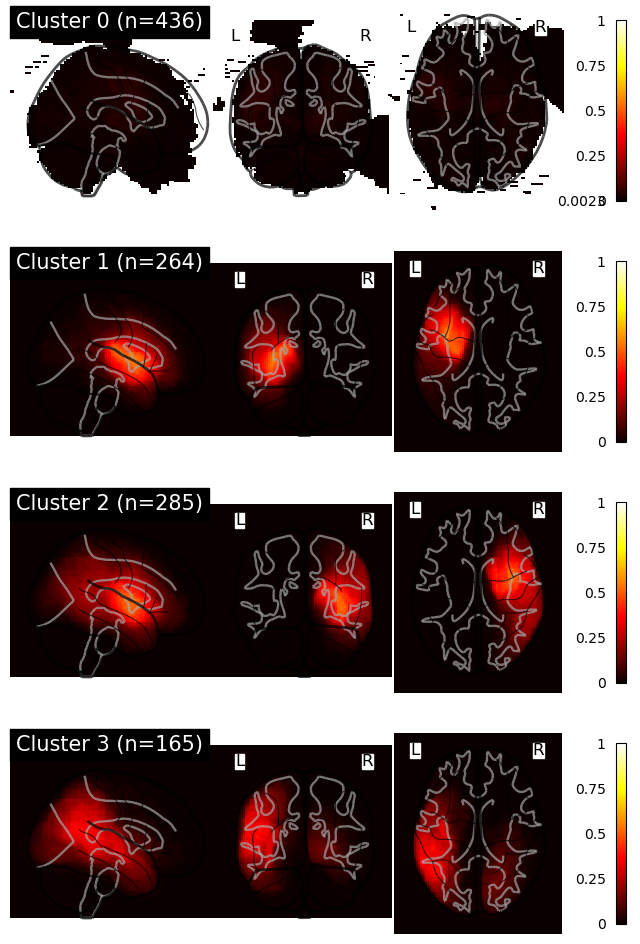

In [7]:
fig, axs = plt.subplots(len(cluster_ids), 1, figsize=(8, 3 * len(cluster_ids)))
if len(cluster_ids) == 1:
    axs = [axs]

for ax, cluster_id in zip(axs, cluster_ids):
    n_subjects = (cluster_of_subject["cluster_label"] == cluster_id).sum()
    plotting.plot_glass_brain(
        overlap_maps[cluster_id],
        colorbar=True, vmin=0, vmax=1, cmap="hot",
        title=f"Cluster {cluster_id} (n={n_subjects})",
        axes=ax,
    )
plt.show()


### 5.2 Ispezione dettagliata di un singolo cluster

Vista anatomica (assiale/coronale/sagittale) a soglia, per un cluster scelto - utile per leggere la localizzazione con più precisione di un glass brain.


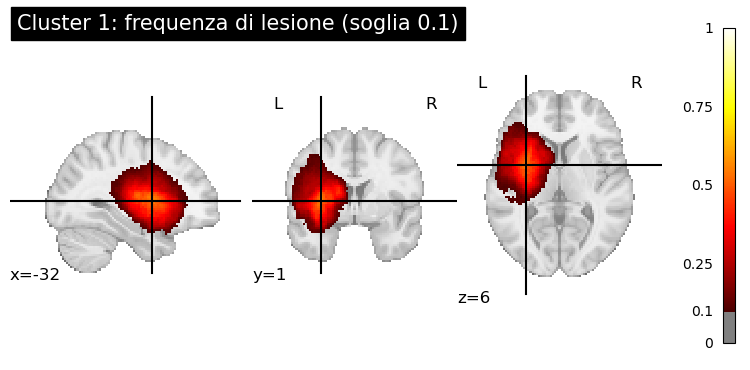

In [8]:
# Cluster da ispezionare in dettaglio (deve essere uno di cluster_ids sopra) - default: quello con l'overlap più concentrato
selected_cluster = max(cluster_ids, key=lambda cluster_id: overlap_maps[cluster_id].get_fdata().max())
# Frequenza minima sotto la quale un voxel non viene mostrato (riduce il rumore di lesioni isolate)
overlap_threshold = 0.1

view = plotting.plot_stat_map(
    overlap_maps[selected_cluster],
    threshold=overlap_threshold,
    vmax=1.0,
    cmap="hot",
    display_mode="ortho",
    title=f"Cluster {selected_cluster}: frequenza di lesione (soglia {overlap_threshold})",
)
plt.show()
